## Notebook 05 - Spectrogram Analysis
### Research Question
If RMS Energy is similar, do the spectrograms reveal differences between normal and abnormal recordings?
### Motivation
The previous notebook showed that RMS Energy alone cannot distinguish all anomalies. This notebook investigates whether time-frequency representations reveal hidden structural changes.

### Imports

In [18]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.dataset import *
from src.io import *
from src.visualization import *

In [3]:
overlap_df = pd.read_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_overlap_files.csv")
overlap_df.head()

,file_name,label,rms
0,00000131.wav,Abnormal,0.005000
1,00000126.wav,Abnormal,0.005141
2,00000127.wav,Abnormal,0.005186
3,00000125.wav,Abnormal,0.005210
4,00000129.wav,Abnormal,0.005221


### Selecting representative recordings

<b>Group A - </b>Normal Baseline

<b>Group B - </b>Overlapping Anomalies

<b>Group C - </b>Obvious Anomalies

In [4]:
# Group A - Normal Baseline
normal_df = pd.read_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_summary.csv")
normal_df = normal_df[normal_df.label == "Normal"].copy()
median_rms = normal_df.rms.median()
normal_df["distance"] = (normal_df.rms - median_rms).abs()
group_a = normal_df.nsmallest(5, "distance")
group_a

,file_name,label,rms,distance
317,00000317.wav,Normal,0.006010,1.288500e-07
527,00000527.wav,Normal,0.006011,1.288500e-07
485,00000485.wav,Normal,0.006010,2.021500e-07
507,00000507.wav,Normal,0.006011,2.648500e-07
640,00000640.wav,Normal,0.006010,7.048500e-07


In [5]:
# Group B - Overlapping anomalies
group_b = overlap_df.sample(5, random_state = 42)
group_b

,file_name,label,rms
27,00000108.wav,Abnormal,0.005676
39,00000097.wav,Abnormal,0.005808
26,00000103.wav,Abnormal,0.005653
43,00000093.wav,Abnormal,0.005851
24,00000106.wav,Abnormal,0.005619


In [6]:
# Group C - Obvious anomalies
normal_max = normal_df.rms.max()
abnormal_df = pd.read_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_summary.csv")
abnormal_df = abnormal_df[abnormal_df.label == 'Abnormal']
group_c = abnormal_df[abnormal_df.rms > normal_max].sample(5, random_state = 42)
group_c

,file_name,label,rms
1086,00000080.wav,Abnormal,0.014035
1083,00000077.wav,Abnormal,0.008632
1079,00000073.wav,Abnormal,0.008021
1146,00000140.wav,Abnormal,0.010800
1039,00000033.wav,Abnormal,0.009946


### Ploting Spectrograms

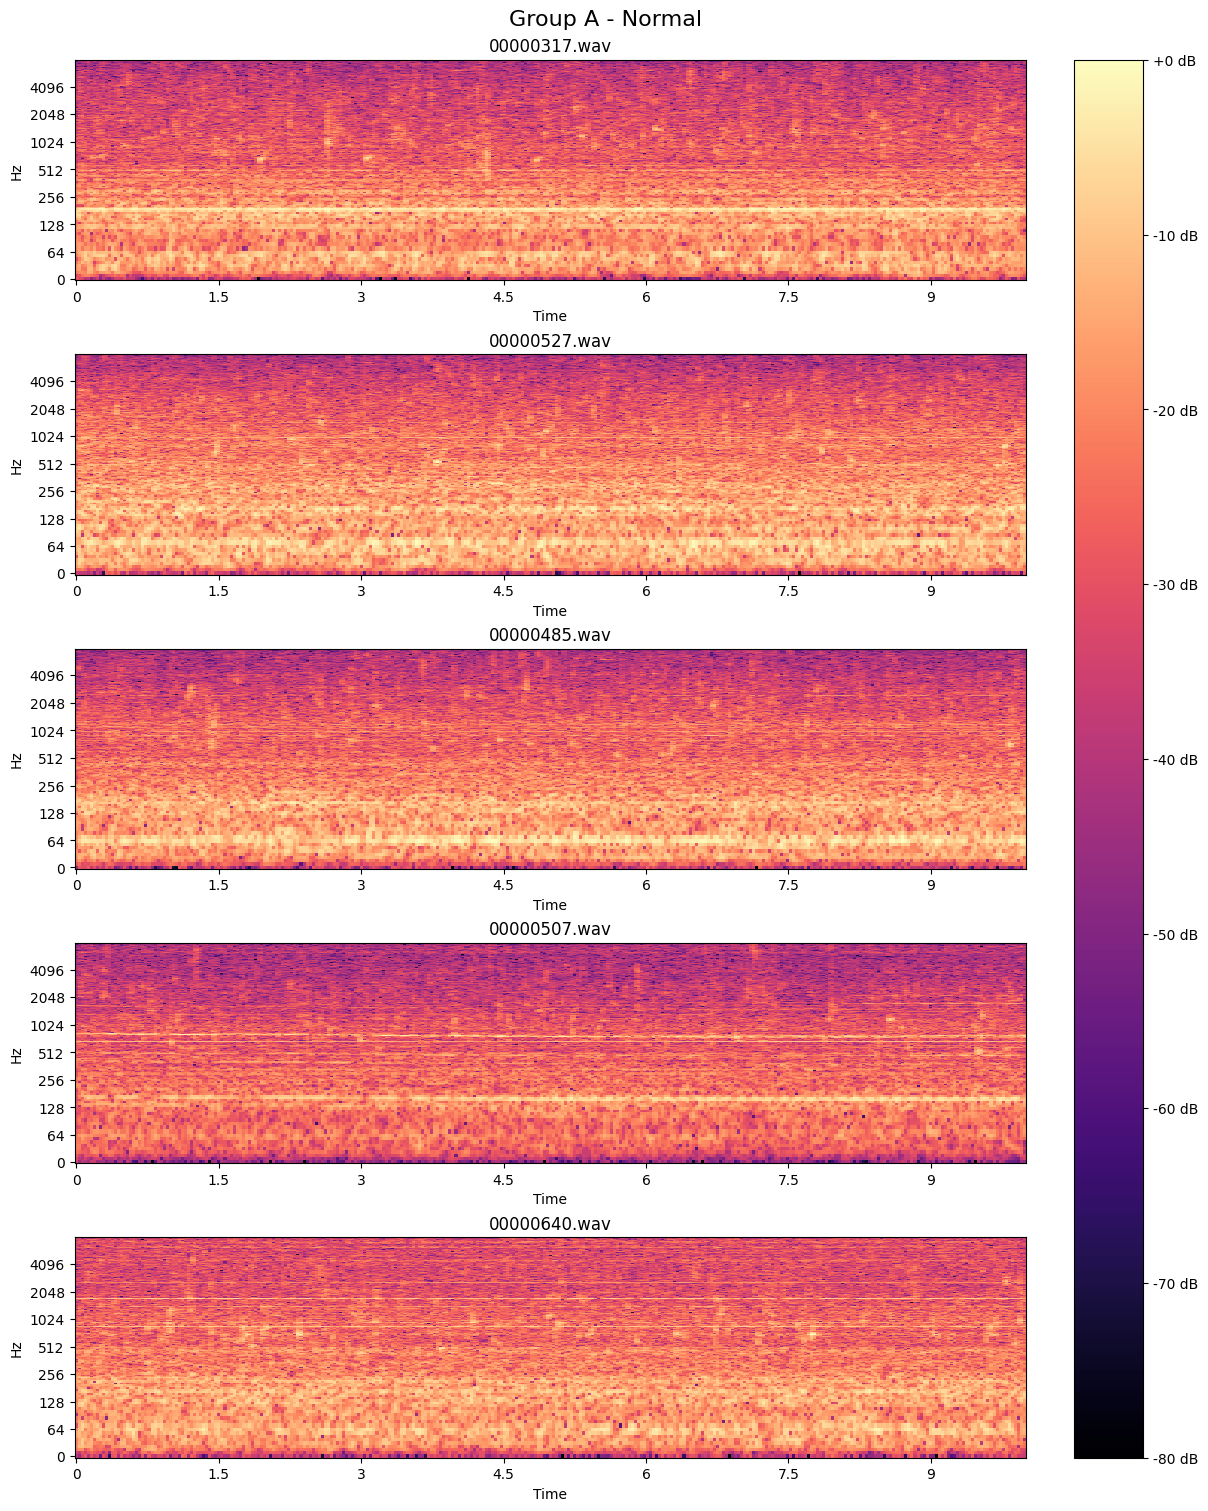

In [7]:
plot_group_spectrograms(dataframe = group_a, folder = normal_path, channel = channel, title = "Group A - Normal")

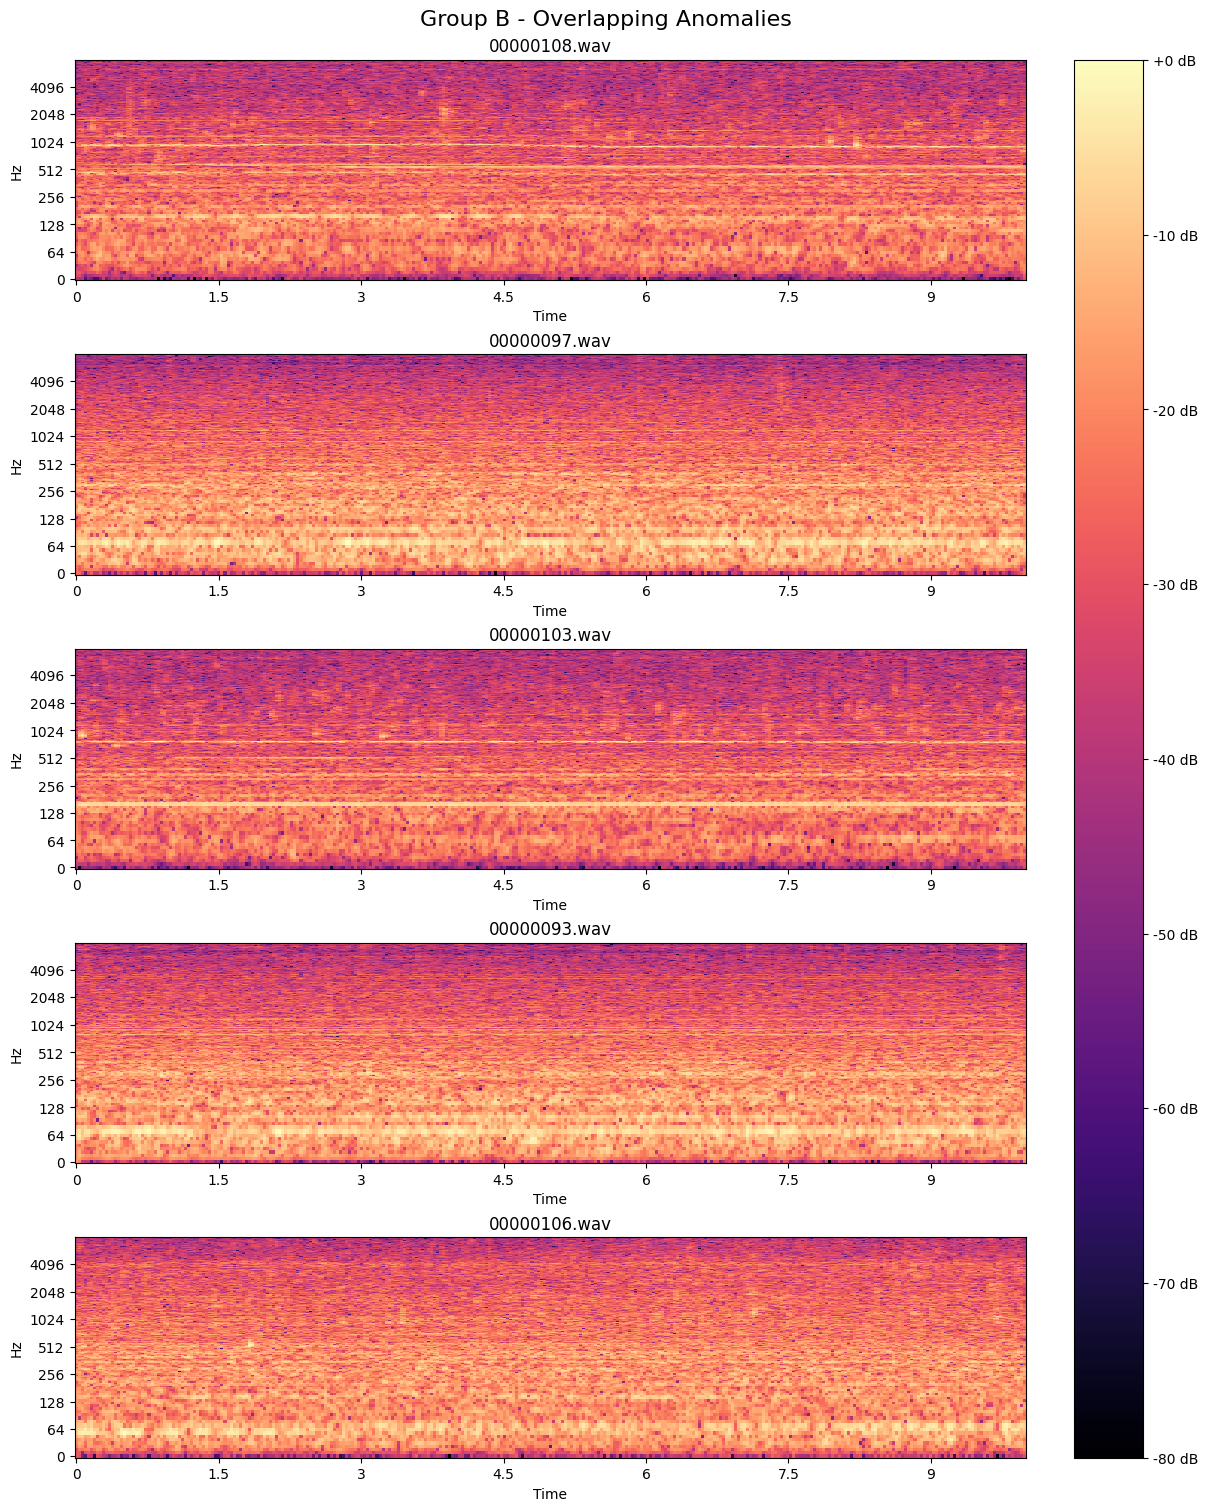

In [8]:
plot_group_spectrograms(dataframe = group_b, folder = abnormal_path, channel = channel, title = "Group B - Overlapping Anomalies")

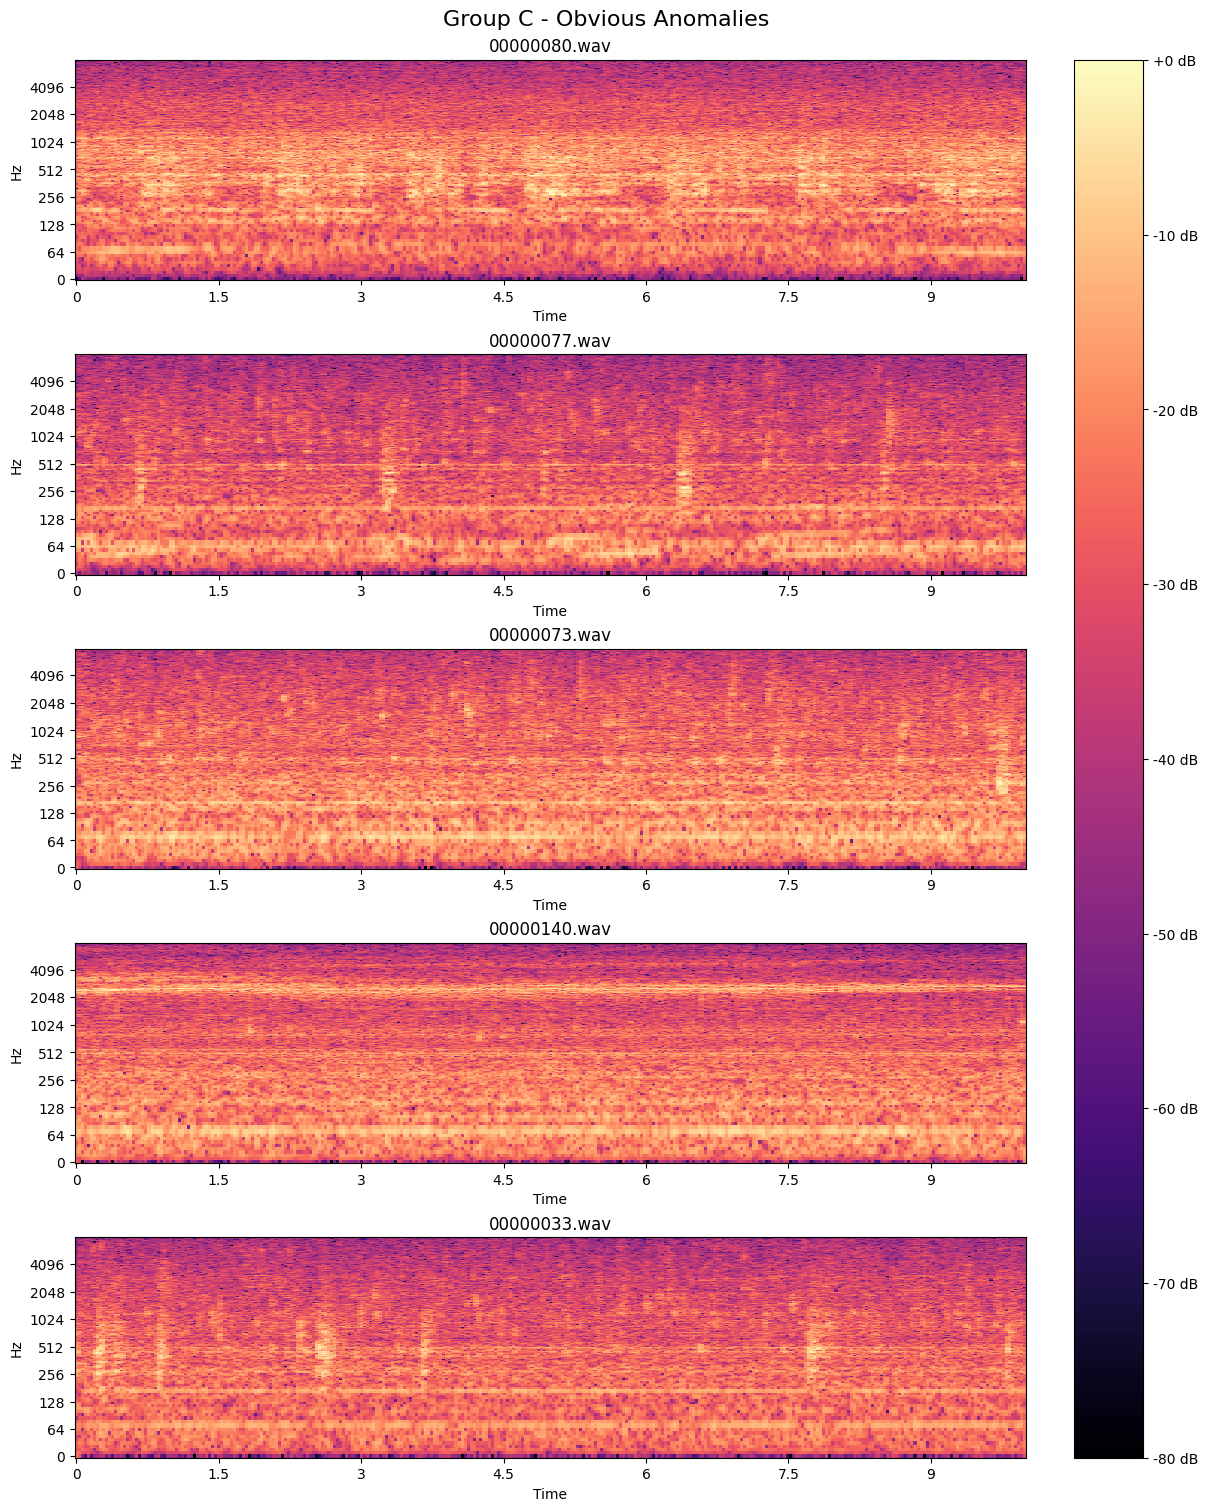

In [9]:
plot_group_spectrograms(dataframe = group_c, folder = abnormal_path, channel = channel, title = "Group C - Obvious Anomalies")

<b> Comparison Table</b>
<table>
    <tr>
        <th>Property</th>
        <th>Group A</th>
        <th>Group B</th>
        <th>Group C</th>
    </tr>
    <tr>
        <td><b>Stable horizontal bands</b></td>
        <td>Yes - low-frequency band only</td>
        <td>Yes - baseline band plus extra narrow tonal lines</td>
        <td>Present in some files, but overshadowed by transients</td>
    </tr>
    <tr>
        <td><b>Broadband bursts</b></td>
        <td>No</td>
        <td>No/ very faint</td>
        <td>Yes - clear vertical streaks in multiple files</td>
    </tr>
    <tr>
        <td><b>Sudden temporal changes</b></td>
        <td>No - stationary throughout</td>
        <td>No - stationary, anomaly is constant/ tonal</td>
        <td>Yes - abrupt, localized events visible at specific timestamps</td>
    </tr>
    <tr>
        <td><b>High frequency activity</b></td>
        <td> Low, diffuse noise only</td>
        <td>Low, diffuse, with occasional added tone</td>
        <td>Elevated/structured in places; bursts also extend into high frequencies.</td>
    </tr>
    <tr>
        <td><b>Low- frequency changes</b></td>
        <td>Stable, consistent band (<200 Hz)</td>
        <td>Stable, but with an added persistent tone (~150 Hz)</td>
        <td>Generally stable baseline, but bursts also show energy at low frequencies during transient events.</td>
    </tr>
</table>

### Notes

1. <b>Normal Baseline (Group A)</b>

* Spectral energy is concentrated in a persistent low-frequency band (<200 Hz), consistent across all samples — likely representing steady machine/engine hum or background operational noise.
* Remaining spectrum shows a smooth, random broadband noise floor with no structured tonal or transient features.
* Time-invariant: spectral characteristics remain statistically stable across the full observation window (no bursts, no drift).
* Serves as the reference pattern — any deviation from this baseline (new tones, bursts, band shifts) indicates a potential anomaly.

2. <b>Subtle Anomalies (Group B)</b>

* Retains the same baseline structure as Group A (low-frequency band + broadband noise floor), making these harder to distinguish at a glance.
* Key difference: presence of additional stable, narrow-band tonal lines at consistent frequencies (e.g., ~150 Hz, ~700–800 Hz) superimposed on the normal pattern.
* These tones are continuous and stationary in time — not sudden events — suggesting a persistent underlying condition (e.g., resonance, bearing wear, electrical interference) rather than a discrete fault event.
* Classified as "overlapping" anomalies because the abnormal signature coexists with, rather than replaces, the normal baseline — requiring closer spectral comparison (not just visual scanning) to detect.

3. <b>Obvious Anomalies (Group C)</b>

* Characterized by bright vertical streaks spanning most/all frequencies at specific time instances — signatures of broadband transient events (impacts, knocks, clicks).
* Some samples instead show a new stable high-frequency band (~2000–3000 Hz) absent in the baseline, indicating a distinct tonal fault mode.
* Marked by clear temporal non-stationarity — energy patterns change abruptly rather than remaining constant, unlike Groups A and B.
* These anomalies are visually salient and can typically be identified through simple inspection, without needing detailed spectral comparison.

<b>Overall distinction:</b> the progression from A → B → C reflects increasing deviation from baseline — from no anomaly, to a hidden/continuous tonal anomaly, to a loud/discrete transient anomaly — mirroring a typical difficulty gradient in anomaly detection tasks.

Next Question:
The spectrograms reveal qualitative differences.

Can these differences be quantified using spectral features?

In [10]:
group_a.to_csv(results_path/"group_a.csv", index = False)
group_b.to_csv(results_path/"group_b.csv", index = False)
group_c.to_csv(results_path/"group_c.csv", index = False)

### Final Research Insight

Spectrogram analysis suggests that anomalies in Pump id_00 are not a single acoustic phenomenon.

Instead, they appear to form at least two distinct regimes:

Subtle tonal anomalies that preserve the normal baseline while introducing persistent narrow-band components.

Transient anomalies that produce broadband, time-localized energy bursts.

This finding explains why RMS Energy failed to separate all anomalies and motivates the use of higher-level spectral descriptors such as Spectral Centroid, Spectral Bandwidth, and MFCCs.